In [20]:
import glob

import warnings

import numpy as np

import pandas as pd

from scipy.stats import ks_2samp

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.preprocessing import LabelEncoder



warnings.filterwarnings("ignore")



# ============================================================

# SETTINGS

# ============================================================



INPUT_FOLDER = "/kaggle/input"

OUTPUT_FOLDER = "/kaggle/working"

RANDOM_STATE = 42

TEST_SIZE = 0.20

CORRELATION_THRESHOLD = 0.85



AU_PEMAL_FEATURES = 20

MALMEM_FEATURES = 12



DATASETS = {

    "AU-PEMal-2025-V1": "AU-PEMal-2025-V1.csv",

    "AU-PEMal-2025-V2": "AU-PEMal-2025-V2.csv",

    "Obfuscated-MalMem2022": "Obfuscated-MalMem2022.csv"

}



COMMON_REMOVE_COLUMNS = [

    "sha1", "sha256", "md5", "hash", 

    "filename", "file_name", "path", 

    "Family", "Category"

]



MALMEM_REMOVE_COLUMNS = [

    "pslist.nprocs64bit", "handles.nport", 

    "svcscan.interactive_process_services",

    "callbacks.nanonymous", "pslist.nppid", 

    "handles.ntimer", "psxview.not_in_pspcid_list",

    "psxview.not_in_pspcid_list_false_avg",

    "svcscan.shared_process_services"

]



# ============================================================

# FILE FINDING AND LOADING

# ============================================================



def find_file(filename):

    matches = glob.glob(os.path.join(INPUT_FOLDER, "**", filename), recursive=True)

    if not matches:

        print(f"❌ File not found: {filename}")

        return None

    print(f"✅ Found: {matches[0]}")

    return matches[0]



def load_datasets():

    datasets = {}

    print("\n" + "=" * 70)

    print("LOADING DATASETS")

    print("=" * 70)

    

    for name, filename in DATASETS.items():

        path = find_file(filename)

        if path is None:

            continue

        try:

            df = pd.read_csv(path, low_memory=False)

            datasets[name] = df

            print(f"{name}: {len(df):,} rows × {len(df.columns)} columns")

        except Exception as error:

            print(f"❌ Error reading {filename}: {error}")

    return datasets



# ============================================================

# DATA CLEANING FUNCTIONS

# ============================================================



def prepare_target(df):

    """Prepare target column 'Class'"""

    if "Class" in df.columns:

        if df["Class"].dtype == "object":

            df["Class"] = df["Class"].apply(

                lambda x: 0 if str(x).strip().lower() in ["benign", "goodware", "0"] else 1

            )

    elif "Category" in df.columns:

        df["Class"] = df["Category"].apply(

            lambda x: 0 if str(x).strip().lower() in ["benign", "goodware", "0"] else 1

        )

    else:

        raise ValueError("No 'Class' or 'Category' target column found.")

    

    df["Class"] = pd.to_numeric(df["Class"], errors="coerce").fillna(1).astype(int)

    return df



def remove_unnecessary_columns(df, dataset_name):

    """Remove identifier and unnecessary columns"""

    columns_to_remove = []

    

    for column in COMMON_REMOVE_COLUMNS:

        if column in df.columns and column != "Class":

            columns_to_remove.append(column)

    

    if dataset_name == "Obfuscated-MalMem2022":

        for column in MALMEM_REMOVE_COLUMNS:

            if column in df.columns:

                columns_to_remove.append(column)

    

    columns_to_remove = list(dict.fromkeys(columns_to_remove))

    if columns_to_remove:

        df = df.drop(columns=columns_to_remove, errors="ignore")

    

    print(f"Unnecessary columns removed: {len(columns_to_remove)}")

    return df



def convert_features_to_numeric_safely(df):

    """Safely converts features to numeric via LabelEncoding instead of discarding string rows."""

    feature_columns = [col for col in df.columns if col != "Class"]

    

    for column in feature_columns:

        if df[column].dtype == 'object':

            # Check if values are mostly numeric strings

            converted = pd.to_numeric(df[column], errors='coerce')

            if converted.isnull().mean() < 0.5:

                df[column] = converted.fillna(converted.median())

            else:

                # Apply Label Encoding to categorical text features

                le = LabelEncoder()

                df[column] = le.fit_transform(df[column].astype(str))

        else:

            df[column] = pd.to_numeric(df[column], errors='coerce')

            

    return df



def handle_missing_values(df):

    """Imputes missing feature values using median and drops rows with missing labels."""

    before = len(df)

    

    # Drop rows where target is missing

    df = df.dropna(subset=['Class']).reset_index(drop=True)

    

    # Fill feature NaNs with Median

    feature_cols = [c for c in df.columns if c != 'Class']

    if df[feature_cols].isnull().sum().sum() > 0:

        df[feature_cols] = df[feature_cols].apply(lambda x: x.fillna(x.median()))

        

    removed = before - len(df)

    print(f"Rows with missing target values removed: {removed:,}")

    return df



def remove_duplicates(df):

    """Remove exact duplicate rows"""

    before = len(df)

    df = df.drop_duplicates(keep="first").reset_index(drop=True)

    removed = before - len(df)

    print(f"Exact duplicate rows removed: {removed:,}")

    return df



def remove_constant_features(df):

    """Remove constant features"""

    feature_columns = [col for col in df.columns if col != "Class"]

    constant_columns = [col for col in feature_columns if df[col].nunique() <= 1]

    

    if constant_columns:

        df = df.drop(columns=constant_columns)

    

    print(f"Constant features removed: {len(constant_columns)}")

    return df



def remove_highly_correlated_features(df, threshold=CORRELATION_THRESHOLD):

    """Remove highly correlated features"""

    feature_columns = [col for col in df.columns if col != "Class"]

    if len(feature_columns) < 2:

        return df

    

    correlation_matrix = df[feature_columns].corr().abs()

    upper = correlation_matrix.where(

        np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)

    )

    

    columns_to_remove = [

        column for column in upper.columns 

        if any(upper[column] > threshold)

    ]

    

    if columns_to_remove:

        df = df.drop(columns=columns_to_remove)

    

    print(f"Highly correlated features removed: {len(columns_to_remove)}")

    return df



# ============================================================

# FEATURE SELECTION

# ============================================================



def select_top_features_rf(X, y, n_features):

    model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)

    model.fit(X, y)

    importance = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_}).sort_values('Importance', ascending=False)

    return importance.head(n_features)['Feature'].tolist()



def select_top_features_mutual_info(X, y, n_features):

    selector = SelectKBest(score_func=mutual_info_classif, k=min(n_features, X.shape[1]))

    selector.fit(X, y)

    scores = pd.DataFrame({'Feature': X.columns, 'Score': selector.scores_}).sort_values('Score', ascending=False)

    return scores.head(n_features)['Feature'].tolist()



def select_top_features_hybrid(X, y, n_features):

    rf_features = select_top_features_rf(X, y, min(n_features * 2, X.shape[1]))

    mi_features = select_top_features_mutual_info(X, y, min(n_features * 2, X.shape[1]))

    

    all_features = rf_features + mi_features

    feature_counts = pd.Series(all_features).value_counts()

    selected_features = feature_counts.head(n_features).index.tolist()

    return selected_features



# ============================================================

# VALIDATION & SIMILARITY

# ============================================================



def check_distribution_similarity(X_train, X_test):

    print("\n" + "-" * 70)

    print("FEATURE DISTRIBUTION SIMILARITY (TRAIN vs TEST)")

    print("-" * 70)

    for column in X_train.columns:

        _, p_value = ks_2samp(X_train[column], X_test[column])

        status = "⚠️ Similar distributions" if p_value > 0.05 else "✓ Distributions differ"

        print(f"{column:30s} p={p_value:.4f}     {status}")



def validate_dataset(df, dataset_name):

    print("\n" + "=" * 70)

    print(f"FINAL VALIDATION: {dataset_name}")

    print("=" * 70)

    print(f"Rows    : {len(df):,}")

    print(f"Features: {len(df.columns) - 1}")

    print(f"Columns : {len(df.columns)}")

    

    benign = (df["Class"] == 0).sum()

    malware = (df["Class"] == 1).sum()

    print(f"Class distribution -> Benign: {benign:,} | Malware: {malware:,}")



# ============================================================

# CLEANING PIPELINE

# ============================================================



def clean_dataset(df, dataset_name):

    print("\n" + "=" * 80)

    print(f"CLEANING: {dataset_name}")

    print("=" * 80)

    print(f"Original shape: {len(df):,} rows × {len(df.columns)} columns")

    

    df = prepare_target(df)

    df = remove_unnecessary_columns(df, dataset_name)

    df = convert_features_to_numeric_safely(df)

    df = handle_missing_values(df)

    df = remove_duplicates(df)

    df = remove_constant_features(df)

    df = remove_highly_correlated_features(df)

    

    X = df.drop(columns=["Class"])

    y = df["Class"]

    

    n_features = AU_PEMAL_FEATURES if dataset_name.startswith("AU-PEMal") else MALMEM_FEATURES

    print(f"\nFEATURE SELECTION: Reducing to {n_features} features")

    selected_features = select_top_features_hybrid(X, y, n_features)

    df = df[selected_features + ["Class"]]

    

    X = df.drop(columns=["Class"])

    y = df["Class"]

    if len(X) > 1:

        X_train, X_test, _, _ = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

        check_distribution_similarity(X_train, X_test)

        

    validate_dataset(df, dataset_name)

    

    output_file = os.path.join(OUTPUT_FOLDER, f"{dataset_name}_Cleaned.csv")

    df.to_csv(output_file, index=False)

    print(f"✅ SAVED: {output_file}")

    return df



# ============================================================

# EXECUTION

# ============================================================



if __name__ == "__main__":

    datasets = load_datasets()

    cleaned_datasets = {}



    for dataset_name, df in datasets.items():

        try:

            cleaned_datasets[dataset_name] = clean_dataset(df.copy(), dataset_name)

        except Exception as error:

            print(f"\n❌ ERROR cleaning {dataset_name}: {error}")



    print("\n" + "=" * 80)

    print("CLEANING COMPLETED SUCCESSFULLY")

    print("=" * 80) 




LOADING DATASETS
✅ Found: /kaggle/input/datasets/abdibakala/resilient-one/AU-PEMal-2025-V1.csv
AU-PEMal-2025-V1: 21,703 rows × 39 columns
✅ Found: /kaggle/input/datasets/abdibakala/resilient-one/AU-PEMal-2025-V2.csv
AU-PEMal-2025-V2: 21,703 rows × 39 columns
✅ Found: /kaggle/input/datasets/abdibakala/resilient-one/Obfuscated-MalMem2022.csv
Obfuscated-MalMem2022: 58,596 rows × 57 columns

CLEANING: AU-PEMal-2025-V1
Original shape: 21,703 rows × 39 columns
Unnecessary columns removed: 3
Rows with missing target values removed: 0
Exact duplicate rows removed: 131
Constant features removed: 0
Highly correlated features removed: 3

FEATURE SELECTION: Reducing to 20 features

----------------------------------------------------------------------
FEATURE DISTRIBUTION SIMILARITY (TRAIN vs TEST)
----------------------------------------------------------------------
processes_malicious            p=1.0000     ⚠️ Similar distributions
files_malicious                p=0.9949     ⚠️ Similar distri


Evaluating: AU-PEMal-2025-V1
Selected features: 12
Data Split: Train=15100 (70%), Val=3236 (15%), Test=3236 (15%)
Model: Random Forest
Validation Accuracy: 0.9215

Performance Metrics (Test Set)
----------------------------------------
TPR (Detection Rate)               : 0.8970
FPR                                : 0.0582
Total Accuracy                     : 0.9193
Precision                          : 0.9393
F1-Score                           : 0.9176
G-Mean                             : 0.9191
ROC-AUC                            : 0.9773
Balanced Accuracy                  : 0.9194
Robust Accuracy                    : 0.6496
Adversarial Robustness Score       : 0.7558

Confusion Matrix
----------------------------------------
TP: 1,454
FP: 94
TN: 1,521
FN: 167


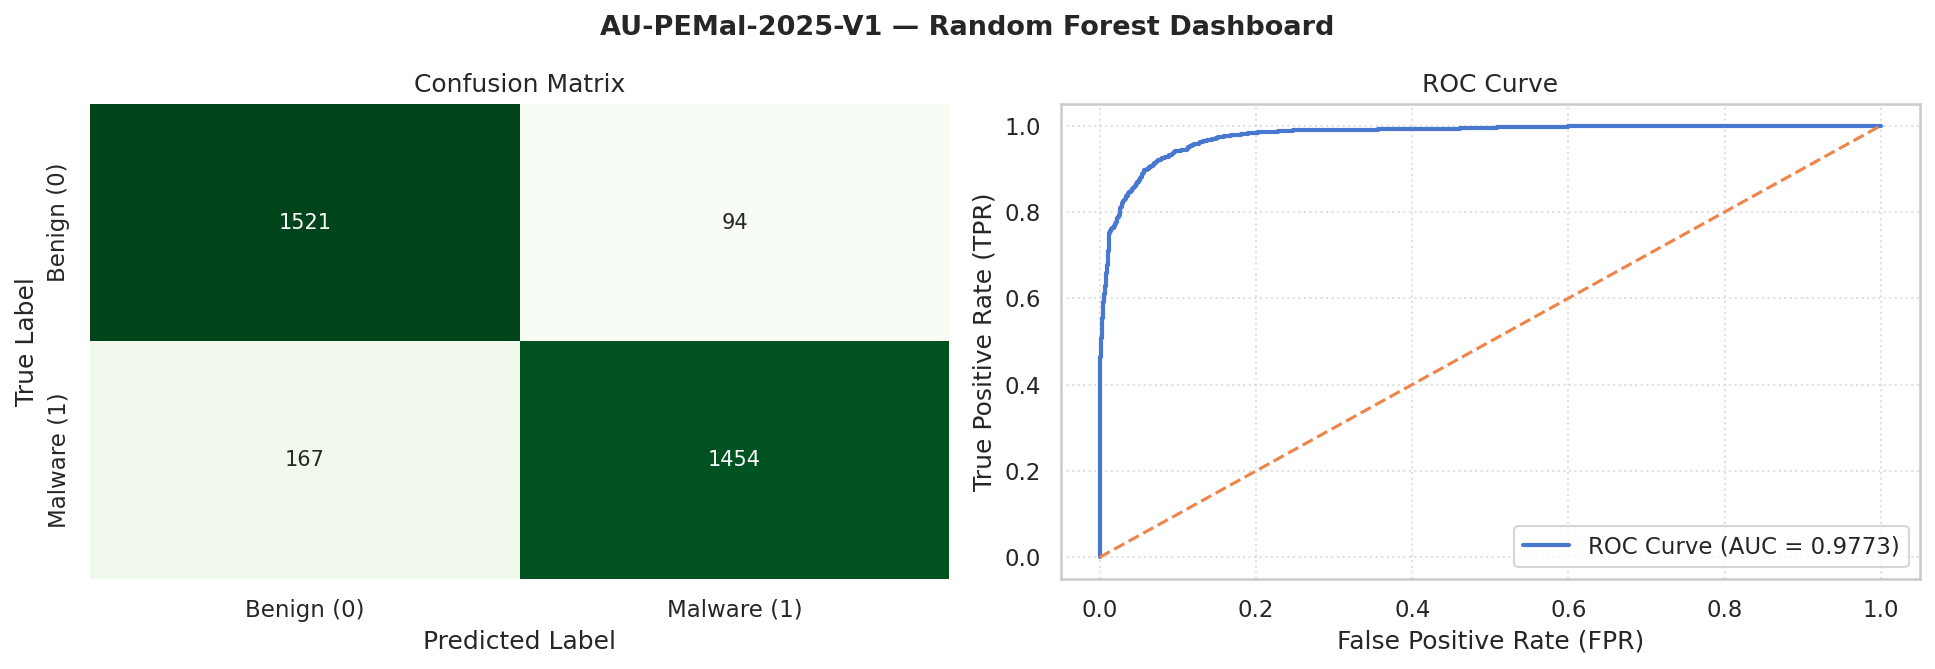


Evaluating: AU-PEMal-2025-V2
Selected features: 12
Data Split: Train=15100 (70%), Val=3236 (15%), Test=3236 (15%)
Model: Random Forest
Validation Accuracy: 0.9104

Performance Metrics (Test Set)
----------------------------------------
TPR (Detection Rate)               : 0.9031
FPR                                : 0.0910
Total Accuracy                     : 0.9061
Precision                          : 0.9088
F1-Score                           : 0.9059
G-Mean                             : 0.9061
ROC-AUC                            : 0.9695
Balanced Accuracy                  : 0.9061
Robust Accuracy                    : 0.6638
Adversarial Robustness Score       : 0.7332

Confusion Matrix
----------------------------------------
TP: 1,464
FP: 147
TN: 1,468
FN: 157


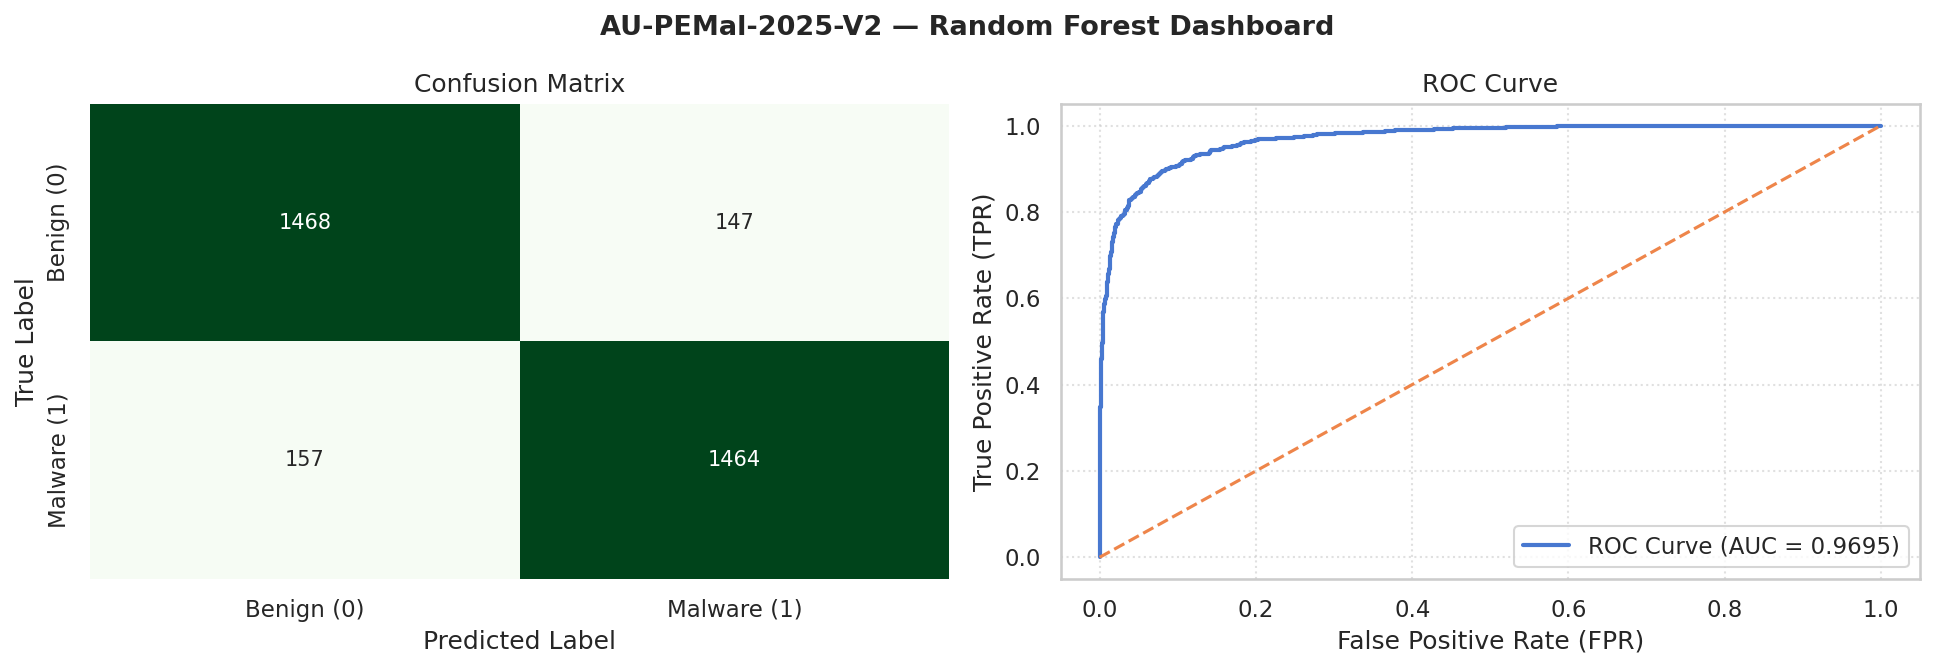


Evaluating: Obfuscated-MalMem2022
Selected features: 4
Data Split: Train=40618 (70%), Val=8704 (15%), Test=8705 (15%)
Model: XGBoost (Regularized)
Validation Accuracy: 0.9773

Performance Metrics (Test Set)
----------------------------------------
TPR (Detection Rate)               : 0.9958
FPR                                : 0.0308
Total Accuracy                     : 0.9824
Precision                          : 0.9696
F1-Score                           : 0.9825
G-Mean                             : 0.9824
ROC-AUC                            : 0.9958
Balanced Accuracy                  : 0.9825
Robust Accuracy                    : 0.9524
Adversarial Robustness Score       : 0.9689

Confusion Matrix
----------------------------------------
TP: 4,302
FP: 135
TN: 4,250
FN: 18


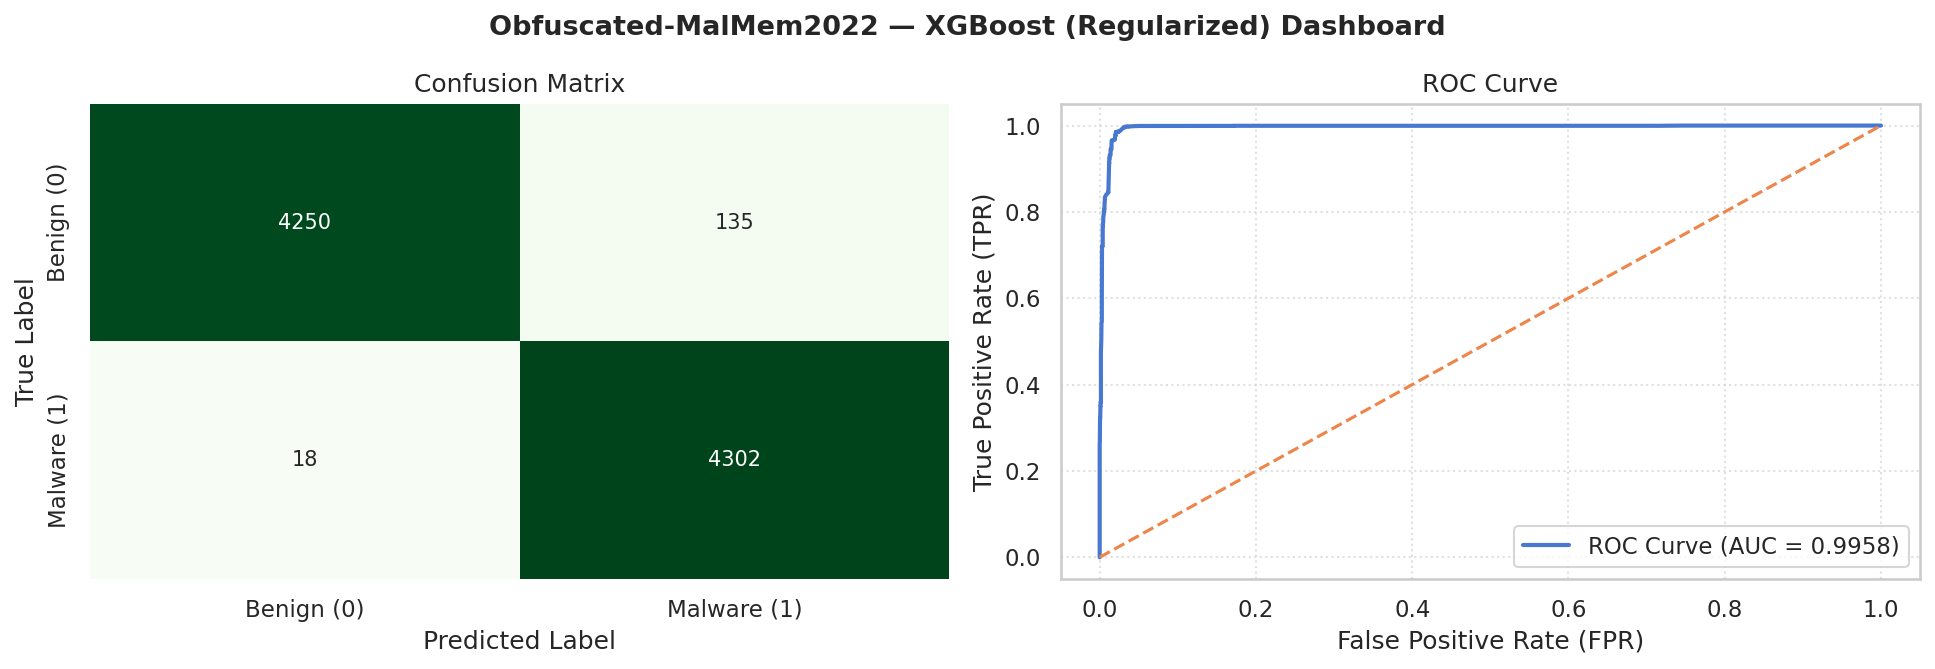


FINAL EVALUATION SUMMARY


,Dataset,Model,Train Samples,Val Samples,Test Samples,TPR (Detection Rate),FPR,Total Accuracy,Precision,F1-Score,G-Mean,ROC-AUC,Balanced Accuracy,Robust Accuracy,Adversarial Robustness Score,TP,FP,TN,FN
0,AU-PEMal-2025-V1,Random Forest,15100,3236,3236,0.896977,0.058204,0.919345,0.939276,0.917640,0.919113,0.977272,0.919386,0.649567,0.755758,1454,94,1521,167
1,AU-PEMal-2025-V2,Random Forest,15100,3236,3236,0.903146,0.091022,0.906057,0.908752,0.905941,0.906058,0.969549,0.906062,0.663782,0.733158,1464,147,1468,157
2,Obfuscated-MalMem2022,XGBoost (Regularized),40618,8704,8705,0.995833,0.030787,0.982424,0.969574,0.982528,0.982433,0.995775,0.982523,0.952441,0.968878,4302,135,4250,18


In [21]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, f1_score, recall_score,
    roc_auc_score, confusion_matrix, balanced_accuracy_score, roc_curve
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# ============================================================
# CONFIGURATION
# ============================================================

INPUT_FOLDER = "/kaggle/working"
OUTPUT_FOLDER = "/kaggle/working"

RANDOM_STATE = 42
CORRELATION_THRESHOLD = 0.85
MI_TOP_K_RATIO = 0.75

LEAKAGE_FEATURES = [
    "processes_malicious", "files_malicious",
    "processes_suspicious", "keys_malicious",
    "registry_malicious", "urls_malicious"
]

MALMEM_TRIVIAL_FEATURES = [
    "dlllist.ndlls", "pslist.nproc", "handles.nhandles",
    "svcscan.nservices", "callbacks.ncallbacks",
    "modules.nmodules", "malfind.commitCharge",
    "malfind.ninjections", "malfind.uniqueInjections",
    "malfind.protection"
]

DATASETS = [
    ("AU-PEMal-2025-V1", "AU-PEMal-2025-V1_Cleaned.csv"),
    ("AU-PEMal-2025-V2", "AU-PEMal-2025-V2_Cleaned.csv"),
    ("Obfuscated-MalMem2022", "Obfuscated-MalMem2022_Cleaned.csv")
]


# ============================================================
# DATA PREPROCESSING
# ============================================================

def preprocess_data(df, dataset_name):
    """Clean data and select the most informative features."""

    target = (
        "Class" if "Class" in df.columns
        else "Category" if "Category" in df.columns
        else df.columns[-1]
    )

    X = df.drop(columns=target)
    y = df[target]

    # Convert class labels to 0 = benign, 1 = malware
    if y.dtype == "object":
        y = y.apply(
            lambda x: 0 if str(x).lower() in ["benign", "0", "goodware"] else 1
        )

    # Remove leakage and trivial features
    drop_cols = [c for c in LEAKAGE_FEATURES if c in X.columns]

    if "MalMem" in dataset_name:
        drop_cols += [c for c in MALMEM_TRIVIAL_FEATURES if c in X.columns]

    X = X.drop(columns=set(drop_cols), errors="ignore")

    # Create MalMem ratio feature
    if "MalMem" in dataset_name:
        if {"pslist.avg_threads", "pslist.avg_handlers"}.issubset(X.columns):
            X["handler_to_thread_ratio"] = (
                X["pslist.avg_handlers"] /
                (X["pslist.avg_threads"] + 1e-5)
            )
            X = X.drop(
                columns=["pslist.avg_threads", "pslist.avg_handlers"]
            )

    # Keep only numeric features
    X = X.select_dtypes(include=np.number)

    # Remove low-variance features
    if X.shape[1] > 0:
        selector = VarianceThreshold(threshold=0.01)
        X = X.loc[:, selector.fit(X).get_support()]

    # Remove highly correlated features
    if X.shape[1] > 1:
        corr = X.corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        drop_corr = [
            col for col in upper.columns
            if any(upper[col] > CORRELATION_THRESHOLD)
        ]
        X = X.drop(columns=drop_corr)

    # Select features using mutual information
    if X.shape[1] > 0:
        scores = mutual_info_classif(
            X, y, random_state=RANDOM_STATE
        )

        ranked_features = (
            pd.Series(scores, index=X.columns)
            .sort_values(ascending=False)
        )

        # Set to 9 features for Obfuscated-MalMem2022
        if "MalMem" in dataset_name:
            n_features = min(9, len(X.columns))
        else:
            n_features = max(
                1, int(len(X.columns) * MI_TOP_K_RATIO)
            )

        X = X[ranked_features.head(n_features).index]

    return X, y


# ============================================================
# MODEL SELECTION
# ============================================================

def create_model(dataset_name):
    """Return the model used for the selected dataset."""

    if "MalMem" in dataset_name:
        return (
            "XGBoost (Regularized)",
            XGBClassifier(
                n_estimators=100,
                max_depth=3,
                learning_rate=0.03,
                colsample_bytree=0.6,
                subsample=0.8,
                random_state=RANDOM_STATE,
                eval_metric="logloss"
            )
        )

    return (
        "Random Forest",
        RandomForestClassifier(
            n_estimators=100,
            max_depth=8,
            min_samples_leaf=4,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced"
        )
    )


# ============================================================
# ADVERSARIAL TESTING
# ============================================================

def adversarial_predictions(model, X_test, noise_level=0.15):
    """Add Gaussian noise and return predictions on perturbed data."""

    X_adv = X_test.copy()

    for col in X_adv.columns:
        std = X_adv[col].std()

        if std > 0:
            noise = np.random.normal(
                0, std * noise_level, len(X_adv)
            )
            X_adv[col] = np.maximum(
                0, np.round(X_adv[col] + noise)
            )

    return model.predict(X_adv)


# ============================================================
# EVALUATION METRICS
# ============================================================

def calculate_metrics(y_true, y_pred, y_prob, y_pred_adv):
    """Calculate standard and adversarial evaluation metrics."""

    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred
    ).ravel()

    tpr = tp / (tp + fn) if tp + fn else 0
    fpr = fp / (fp + tn) if fp + tn else 0
    tnr = 1 - fpr

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    roc_auc = (
        roc_auc_score(y_true, y_prob)
        if y_prob is not None else 0
    )

    g_mean = np.sqrt(tpr * tnr)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)

    robust_acc = accuracy_score(y_true, y_pred_adv)
    f1_adv = f1_score(y_true, y_pred_adv, zero_division=0)

    robustness = 1 - max(
        0, (f1 - f1_adv) / (f1 + 1e-9)
    )

    return {
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
        "TPR (Detection Rate)": tpr,
        "FPR": fpr,
        "Total Accuracy": accuracy,
        "Precision": precision,
        "F1-Score": f1,
        "G-Mean": g_mean,
        "ROC-AUC": roc_auc,
        "Balanced Accuracy": balanced_acc,
        "Robust Accuracy": robust_acc,
        "Adversarial Robustness Score": robustness
    }


# ============================================================
# VISUALIZATION
# ============================================================

def plot_results(y_true, y_pred, y_prob, dataset_name, model_name):
    """Create confusion matrix and ROC curve."""

    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(13, 4.5), dpi=150
    )

    fig.suptitle(
        f"{dataset_name} — {model_name} Dashboard",
        fontsize=13,
        fontweight="bold"
    )

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Greens",
        cbar=False,
        ax=ax1,
        xticklabels=["Benign (0)", "Malware (1)"],
        yticklabels=["Benign (0)", "Malware (1)"]
    )

    ax1.set_title("Confusion Matrix")
    ax1.set_xlabel("Predicted Label")
    ax1.set_ylabel("True Label")

    # ROC curve
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc = roc_auc_score(y_true, y_prob)

        ax2.plot(
            fpr, tpr,
            lw=2,
            label=f"ROC Curve (AUC = {auc:.4f})"
        )

        ax2.plot([0, 1], [0, 1], linestyle="--")

        ax2.set_title("ROC Curve")
        ax2.set_xlabel("False Positive Rate (FPR)")
        ax2.set_ylabel("True Positive Rate (TPR)")
        ax2.legend(loc="lower right")
        ax2.grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()

    output = os.path.join(
        OUTPUT_FOLDER,
        f"{dataset_name}_evaluation_dashboard.png"
    )

    plt.savefig(output, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


# ============================================================
# EVALUATE ONE DATASET
# ============================================================

def evaluate_dataset(dataset_name, filename):
    """Train, validate, test and evaluate one dataset."""

    path = os.path.join(INPUT_FOLDER, filename)

    if not os.path.exists(path):
        print(f"❌ File not found: {path}")
        return None

    print(f"\n{'=' * 70}")
    print(f"Evaluating: {dataset_name}")
    print(f"{'=' * 70}")

    # Load and preprocess
    df = pd.read_csv(path)
    X, y = preprocess_data(df, dataset_name)

    print(f"Selected features: {X.shape[1]}")

    # Step 1: Split into 70% Train and 30% Temporary (Validation + Test)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=RANDOM_STATE,
        stratify=y
    )

    # Step 2: Split the 30% Temporary set equally into 15% Validation and 15% Testing
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        random_state=RANDOM_STATE,
        stratify=y_temp
    )

    print(f"Data Split: Train={len(X_train)} (70%), Val={len(X_val)} (15%), Test={len(X_test)} (15%)")

    # Select model
    model_name, model = create_model(dataset_name)

    print(f"Model: {model_name}")

    # Train model on Training Set
    model.fit(X_train, y_train)

    # Optional Validation check
    val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)
    print(f"Validation Accuracy: {val_acc:.4f}")

    # Final Testing predictions
    y_pred = model.predict(X_test)

    y_prob = (
        model.predict_proba(X_test)[:, 1]
        if hasattr(model, "predict_proba")
        else None
    )

    # Adversarial predictions
    y_pred_adv = adversarial_predictions(
        model, X_test, noise_level=0.15
    )

    # Calculate metrics on Test Set
    metrics = calculate_metrics(
        y_test,
        y_pred,
        y_prob,
        y_pred_adv
    )

    metrics["Dataset"] = dataset_name
    metrics["Model"] = model_name
    metrics["Train Samples"] = len(X_train)
    metrics["Val Samples"] = len(X_val)
    metrics["Test Samples"] = len(X_test)

    # Display results
    print("\nPerformance Metrics (Test Set)")
    print("-" * 40)

    for key in [
        "TPR (Detection Rate)",
        "FPR",
        "Total Accuracy",
        "Precision",
        "F1-Score",
        "G-Mean",
        "ROC-AUC",
        "Balanced Accuracy",
        "Robust Accuracy",
        "Adversarial Robustness Score"
    ]:
        print(f"{key:<35}: {metrics[key]:.4f}")

    print("\nConfusion Matrix")
    print("-" * 40)
    print(f"TP: {metrics['TP']:,}")
    print(f"FP: {metrics['FP']:,}")
    print(f"TN: {metrics['TN']:,}")
    print(f"FN: {metrics['FN']:,}")

    # Plot results
    plot_results(
        y_test,
        y_pred,
        y_prob,
        dataset_name,
        model_name
    )

    return metrics


# ============================================================
# MAIN
# ============================================================

def main():

    results = []

    for dataset_name, filename in DATASETS:
        result = evaluate_dataset(dataset_name, filename)

        if result:
            results.append(result)

    if not results:
        print("❌ No datasets were evaluated.")
        return

    # Create final results table
    results_df = pd.DataFrame(results)

    columns = [
        "Dataset",
        "Model",
        "Train Samples",
        "Val Samples",
        "Test Samples",
        "TPR (Detection Rate)",
        "FPR",
        "Total Accuracy",
        "Precision",
        "F1-Score",
        "G-Mean",
        "ROC-AUC",
        "Balanced Accuracy",
        "Robust Accuracy",
        "Adversarial Robustness Score",
        "TP",
        "FP",
        "TN",
        "FN"
    ]

    results_df = results_df[columns]

    # Save results
    output_file = os.path.join(
        OUTPUT_FOLDER,
        "real_world_malware_evaluation_results.csv"
    )

    results_df.to_csv(output_file, index=False)

    print("\n" + "=" * 70)
    print("FINAL EVALUATION SUMMARY")
    print("=" * 70)

    display(results_df)


# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":
    main()

In [22]:
import zipfile

files = [
    "/kaggle/working/AU-PEMal-2025-V1_evaluation_dashboard.png",
    "/kaggle/working/AU-PEMal-2025-V2_evaluation_dashboard.png",
    "/kaggle/working/Obfuscated-MalMem2022_evaluation_dashboard.png"
]

zip_path = "/kaggle/working/malware_evaluation_dashboards.zip"

with zipfile.ZipFile(zip_path, "w") as zipf:
    for file in files:
        zipf.write(file, arcname=file.split("/")[-1])

print(f"Created: {zip_path}")

Created: /kaggle/working/malware_evaluation_dashboards.zip
